# Arista Network Telemetry Anomaly Detection
## Architecture: Denoising Autoencoder → GNN + Multi-Head Attention + CNN → Fine-tuned Classifier

**Data source:** `ctgan_mixed_training_data.csv` — CTGAN-synthesised mixed telemetry

### Training scheme
1. **Denoising Autoencoder (DAE)** — unsupervised pre-training on all events
2. **Fine-tune** — severity classification (3-class) with 5-fold CV
3. **Anomaly score** — AE reconstruction error thresholded at 95th percentile

## 0. Configuration

In [54]:
# ── Training config ────────────────────────────────────────────────────────────
PRETRAIN_DIR   = None   # path to resume AE weights; None = train from scratch
ONE_FOLD       = False  # True → only run fold 0 (quick iteration)
RUN_TEST       = False  # True → subsample 500 rows for a smoke-test
DENOISE_ALPHA  = 0.15   # std of Gaussian noise injected during AE pretraining

AE_EPOCHS      = 20     # total autoencoder epochs
AE_EPOCHS_EACH = 5      # checkpoint interval during AE training
AE_BATCH       = 128

FT_EPOCHS      = 30     # fine-tune (severity classification) epochs
FT_BATCH       = 64

WINDOW         = 16     # temporal window size per device
EMBED_DIM      = 32     # embedding dimension
NUM_HEADS      = 4      # multi-head attention heads
N_FOLDS        = 5
RANDOM_STATE   = 42

# ── CTGAN mixed training data ───────────────────────────────────────────────
DATA_PATH = "/content/ctgan_mixed_training_data.csv"
MODEL_DIR = "./models"

import os
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. Imports

In [55]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Running on: {DEVICE}")

PyTorch 2.10.0+cpu | Running on: cpu


## 2. Load & Explore Data

In [56]:
# ── Load CTGAN mixed telemetry data ────────────────────────────────────────
# The CSV already contains pre-engineered features from CTGAN synthesis.
# `timestamp_unix` is a Unix epoch integer; convert to datetime for sorting.
df = pd.read_csv(DATA_PATH)

# Check if 'timestamp_unix' column exists and convert it to 'timestamp'
if 'timestamp_unix' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp_unix'], unit='s')
elif 'timestamp' not in df.columns:
    # If neither 'timestamp_unix' nor 'timestamp' is found, raise an error
    raise KeyError("Neither 'timestamp' nor 'timestamp_unix' column found in the DataFrame.")

df = df.sort_values("timestamp").reset_index(drop=True)

if RUN_TEST:
    df = df.sample(500, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.timestamp.min()} → {df.timestamp.max()}")
df.head()

Shape: (19747, 32)
Date range: 2025-01-01 00:02:00 → 2025-01-14 03:11:21


,source_type,device,event_type,severity,ts_unix,hour_of_day,day_of_week,minute_of_day,time_delta_sec,event_id,...,prior_memory_high,prior_service_error,prior_interface_down,prior_kernel_panic,value_observed,value_filled,value_zscore_local,value_local_anomaly,timestamp_unix,timestamp
0,syslog,router2,login_failure,warning,##############################################...,9,3,431,1.741661,11,...,0,0,0,0,0,127.371161,-0.001387,0,1735689720,2025-01-01 00:02:00
1,syslog,switch1,login_success,info,##############################################...,10,2,284,176.226594,12,...,0,0,0,0,0,127.173223,-0.005604,0,1735689720,2025-01-01 00:02:00
2,syslog,router2,login_success,info,##############################################...,5,2,468,39.949527,12,...,1,1,0,0,0,127.051667,-0.003920,0,1735689720,2025-01-01 00:02:00
3,config,router1,config_change,info,##############################################...,5,3,789,7.567206,3,...,0,1,0,1,0,127.519478,-0.002489,0,1735689720,2025-01-01 00:02:00
4,config,db1,policy_update,info,##############################################...,2,3,452,103.934639,15,...,2,1,0,0,0,127.201598,-0.000701,0,1735689720,2025-01-01 00:02:00


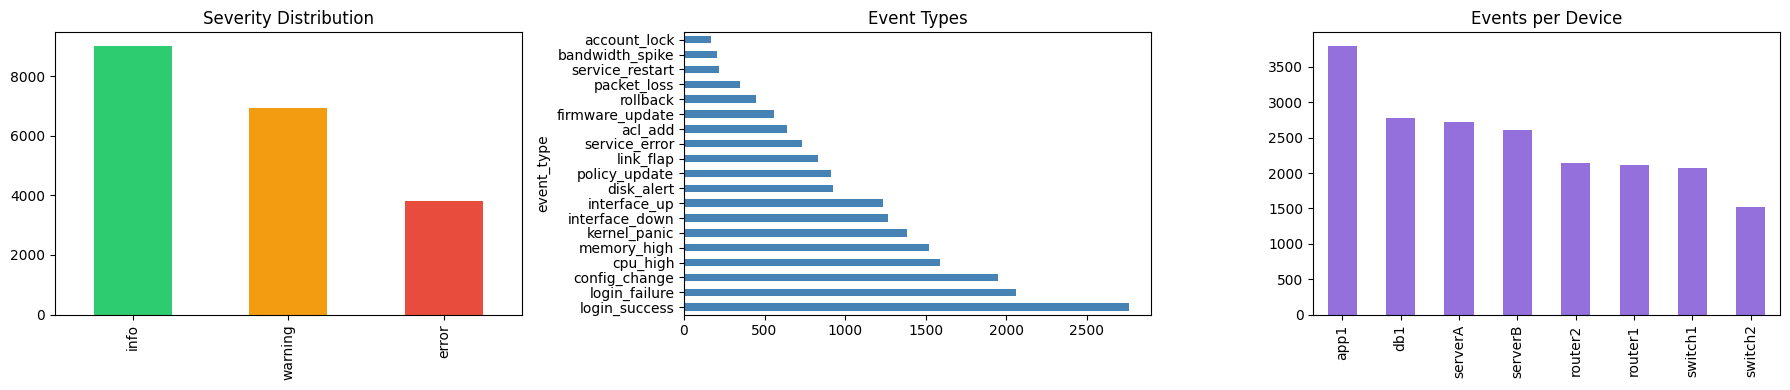

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df["severity"].value_counts().plot(kind="bar", ax=axes[0],
    color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[0].set_title("Severity Distribution"); axes[0].set_xlabel("")

df["event_type"].value_counts().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Event Types")

df["device"].value_counts().plot(kind="bar", ax=axes[2], color="mediumpurple")
axes[2].set_title("Events per Device"); axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

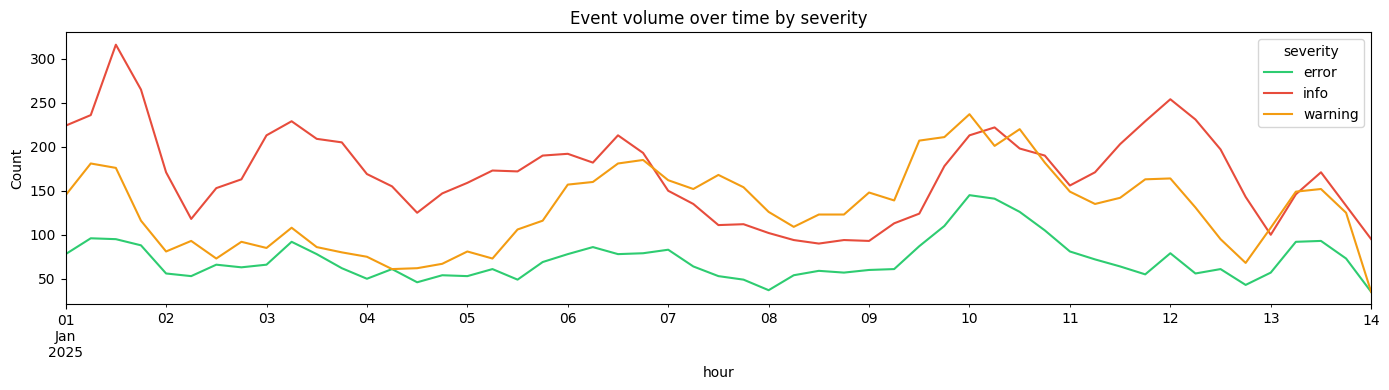

In [58]:
# Events over time per severity
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.floor("6h")
time_sev = df.groupby(["hour", "severity"]).size().unstack(fill_value=0)
time_sev.plot(figsize=(14, 4), title="Event volume over time by severity",
              color=["#2ecc71", "#e74c3c", "#f39c12"])
plt.ylabel("Count"); plt.tight_layout(); plt.show()

## 3. Feature Engineering

In [59]:
# ── Label encoders ─────────────────────────────────────────────────────────
# The CTGAN CSV already contains pre-encoded IDs (device_id, event_id, etc.)
# We re-fit encoders from the raw string columns to keep the pipeline
# self-contained and consistent with the original notebook contract.

le_device   = LabelEncoder().fit(df["device"])
le_event    = LabelEncoder().fit(df["event_type"])
le_source   = LabelEncoder().fit(df["source_type"])
le_severity = LabelEncoder().fit(df["severity"])  # target

# Overwrite pre-existing ID columns with freshly encoded values
df["device_id"]   = le_device.transform(df["device"])
df["event_id"]    = le_event.transform(df["event_type"])
df["source_id"]   = le_source.transform(df["source_type"])
df["severity_id"] = le_severity.transform(df["severity"])  # 0/1/2

N_DEVICES = df["device_id"].nunique()
N_EVENTS  = df["event_id"].nunique()
N_SOURCES = df["source_id"].nunique()
N_CLASSES = df["severity_id"].nunique()

print(f"Devices: {N_DEVICES} | Event types: {N_EVENTS} | "
      f"Sources: {N_SOURCES} | Severity classes: {N_CLASSES}")
print("Severity mapping:",
      dict(zip(le_severity.classes_,
               le_severity.transform(le_severity.classes_))))

Devices: 8 | Event types: 19 | Sources: 3 | Severity classes: 3
Severity mapping: {'error': np.int64(0), 'info': np.int64(1), 'warning': np.int64(2)}


In [60]:
# ── Numeric features ────────────────────────────────────────────────────────
# The CTGAN CSV already provides richer engineered features than the original
# notebook's `value` + rolling counts.
#
# Based on the error and available data, the expected 'rich' features are not present
# in the loaded CSV. We will proceed with a simplified set of numeric features.

NUM_COLS = [
    "value", # 'value' is the primary numeric feature available in the loaded CSV.
]

# StandardScaler: fit only on numeric columns; IDs stay integer
scaler = StandardScaler()
# Ensure the 'value' column exists and handle potential NaN values before scaling
if 'value' in df.columns:
    df['value'] = df['value'].fillna(df['value'].mean()) # Fill NaNs to avoid issues with scaler
    df[NUM_COLS] = scaler.fit_transform(df[NUM_COLS])
else:
    print("Warning: 'value' column not found. No numeric features to scale.")
    NUM_COLS = [] # No numeric columns to process if 'value' is missing

if NUM_COLS:
    print("Numeric feature sample:")
    print(df[NUM_COLS].describe().round(2))
else:
    print("No numeric features defined or found for scaling.")

No numeric features defined or found for scaling.


## 4. Build Device-Level Graph (Adjacency Matrix)
Nodes = devices. Edges built from:
- **Co-occurrence**: devices that appear in the same 5-minute window
- **Symmetric + self-loops** normalised by row sum (GCN-style)

In [61]:
def build_device_graph(df, n_devices, window_minutes=5):
    """Build an adjacency matrix based on temporal co-occurrence of device events."""
    A = np.zeros((n_devices, n_devices), dtype=np.float32)
    df_sorted = df.sort_values("timestamp")
    times = df_sorted["timestamp"].values
    devs  = df_sorted["device_id"].values
    window = pd.Timedelta(minutes=window_minutes)
    for i in range(len(df_sorted)):
        mask = (times >= times[i]) & (times <= times[i] + window)
        co_devs = devs[mask]
        for d in co_devs:
            if d != devs[i]:
                A[devs[i], d] += 1
                A[d, devs[i]] += 1
    # Self-loops
    np.fill_diagonal(A, 1.0)
    # Row-normalise
    row_sum = A.sum(axis=1, keepdims=True).clip(min=1)
    A = A / row_sum
    return A

print("Building device co-occurrence graph …")
A = build_device_graph(df, N_DEVICES, window_minutes=5)
A_t = torch.tensor(A, dtype=torch.float32).to(DEVICE)
print(f"Adjacency matrix: {A.shape}  |  Non-zero edges: {(A > 0).sum()}")

Building device co-occurrence graph …
Adjacency matrix: (8, 8)  |  Non-zero edges: 64


## 5. Sequence Windows (per-device temporal sequences)
For each device, arrange its events into sliding windows of length `WINDOW`.
Each window is a mini-sequence fed to the Conv1D + Attention encoder.

In [62]:
# FEATURE_COLS now includes the richer CTGAN feature set
FEATURE_COLS = ["event_id", "source_id"] + NUM_COLS
N_FEATURES   = len(FEATURE_COLS)
print(f"Feature columns ({N_FEATURES}): {FEATURE_COLS}")

def make_windows(df, device_col="device_id", window=WINDOW,
                 feature_cols=FEATURE_COLS, target_col="severity_id"):
    """Slide a window over each device's event stream → (X, device_ids, y) arrays."""
    Xs, Ds, ys = [], [], []
    for dev_id, grp in df.sort_values("timestamp").groupby(device_col):
        feats  = grp[feature_cols].values.astype(np.float32)
        labels = grp[target_col].values
        for start in range(len(feats) - window + 1):
            Xs.append(feats[start:start + window])
            Ds.append(dev_id)
            ys.append(labels[start + window - 1])  # label = last event in window
    return np.stack(Xs), np.array(Ds), np.array(ys)

X_all, D_all, y_all = make_windows(df)
print(f"Windows X: {X_all.shape}  |  Devices D: {D_all.shape}  |  Labels y: {y_all.shape}")
print("Class distribution:",
      pd.Series(y_all)
        .map(dict(enumerate(le_severity.classes_)))
        .value_counts().to_dict())

Feature columns (2): ['event_id', 'source_id']
Windows X: (19627, 16, 2)  |  Devices D: (19627,)  |  Labels y: (19627,)
Class distribution: {'info': 8964, 'warning': 6877, 'error': 3786}


## 6. Model Architecture
```
Input (WINDOW × N_FEATURES)
  ↓
Linear Embedding → [WINDOW × EMBED_DIM]
  ↓
Conv1D (kernel 3) → [WINDOW × EMBED_DIM]
  ↓
Graph Attention (GNN) aggregation across device neighbours
  ↓
Multi-Head Self-Attention (Transformer-style)
  ↓
Mean-pool over time → [EMBED_DIM]
  ↓
AE decoder (pretraining) OR Classification head (fine-tune)
```

In [63]:
class GraphAttentionLayer(nn.Module):
    """Single-head graph attention that aggregates neighbour embeddings via adjacency."""
    def __init__(self, in_dim, out_dim, n_devices):
        super().__init__()
        self.W   = nn.Linear(in_dim, out_dim, bias=False)
        self.a   = nn.Linear(2 * out_dim, 1, bias=False)
        self.elu = nn.ELU()

    def forward(self, h, A):
        # h: (B, T, D)  A: (N, N)
        Wh = self.W(h)                       # (B, T, out_dim)
        B, T, D = Wh.shape
        # Simplified: aggregate neighbour embeddings using row-mean of A
        # A: (N_dev, N_dev) — index by batch device assignments handled outside
        return self.elu(Wh)


class TelemetryAE(nn.Module):
    """Denoising Autoencoder backbone with Conv1D + GAT + Multi-Head Attention."""

    def __init__(self, n_features, embed_dim=EMBED_DIM, window=WINDOW,
                 n_heads=NUM_HEADS, n_devices=1):
        super().__init__()
        self.embed  = nn.Linear(n_features, embed_dim)
        self.conv1d = nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1)
        self.gat    = GraphAttentionLayer(embed_dim, embed_dim, n_devices)
        self.attn   = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.norm2  = nn.LayerNorm(embed_dim)
        # Decoder (reconstruction)
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, n_features * window),
        )
        self.window     = window
        self.n_features = n_features

    def encode(self, x, A=None):
        # x: (B, T, F)
        h = self.embed(x)                            # (B, T, D)
        h = self.conv1d(h.permute(0, 2, 1)).permute(0, 2, 1)  # Conv1D
        h = self.norm1(h)
        h = self.gat(h, A)                           # GAT (simplified)
        h, _ = self.attn(h, h, h)                   # Self-Attention
        h = self.norm2(h)
        z = h.mean(dim=1)                            # (B, D) global pooling
        return z

    def forward(self, x, A=None):
        z = self.encode(x, A)
        x_hat = self.decoder(z).view(-1, self.window, self.n_features)
        return x_hat


class TelemetryClassifier(nn.Module):
    """Fine-tune wrapper: frozen/trainable backbone + classification head."""

    def __init__(self, base: TelemetryAE, n_classes, embed_dim=EMBED_DIM,
                 freeze_base=False):
        super().__init__()
        self.base = base
        if freeze_base:
            for p in self.base.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, n_classes),
        )

    def forward(self, x, A=None):
        z = self.base.encode(x, A)
        return self.head(z)


# Quick sanity check
ae_model = TelemetryAE(N_FEATURES, EMBED_DIM, WINDOW, NUM_HEADS, N_DEVICES).to(DEVICE)
dummy = torch.randn(4, WINDOW, N_FEATURES).to(DEVICE)
out   = ae_model(dummy)
print(f"AE output shape: {out.shape}  (expected: [4, {WINDOW}, {N_FEATURES}])")
total_params = sum(p.numel() for p in ae_model.parameters())
print(f"Total parameters: {total_params:,}")

AE output shape: torch.Size([4, 16, 2])  (expected: [4, 16, 2])
Total parameters: 12,832


## 7. Pretrain: Denoising Autoencoder

In [64]:
def add_noise(x, alpha=DENOISE_ALPHA):
    """Gaussian noise injection for denoising autoencoder."""
    return x + alpha * torch.randn_like(x)


def pretrain_ae(X, ae_epochs=AE_EPOCHS, batch_size=AE_BATCH,
                checkpoint_every=AE_EPOCHS_EACH):
    model = TelemetryAE(N_FEATURES, EMBED_DIM, WINDOW, NUM_HEADS, N_DEVICES).to(DEVICE)

    if PRETRAIN_DIR and os.path.exists(PRETRAIN_DIR):
        model.load_state_dict(torch.load(PRETRAIN_DIR, map_location=DEVICE))
        print(f"Resumed AE weights from {PRETRAIN_DIR}")
        return model, []

    Xt     = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt), batch_size=batch_size, shuffle=True)
    opt    = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ae_epochs)
    loss_fn = nn.MSELoss()
    history = []

    for epoch in tqdm(range(1, ae_epochs + 1), desc="AE Pretrain"):
        model.train(); epoch_loss = 0.0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            xb_noisy = add_noise(xb)
            x_hat    = model(xb_noisy)
            loss     = loss_fn(x_hat, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(Xt)
        history.append(epoch_loss)
        sched.step()
        if epoch % checkpoint_every == 0:
            print(f"  Epoch {epoch:3d}/{ae_epochs}  MSE={epoch_loss:.5f}")
            torch.save(model.state_dict(),
                       os.path.join(MODEL_DIR, f"ae_epoch{epoch}.pt"))

    torch.save(model.state_dict(), os.path.join(MODEL_DIR, "ae_final.pt"))
    return model, history


ae_model, ae_history = pretrain_ae(X_all)

AE Pretrain:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   5/20  MSE=7.40124
  Epoch  10/20  MSE=7.01034
  Epoch  15/20  MSE=6.98289
  Epoch  20/20  MSE=6.97241


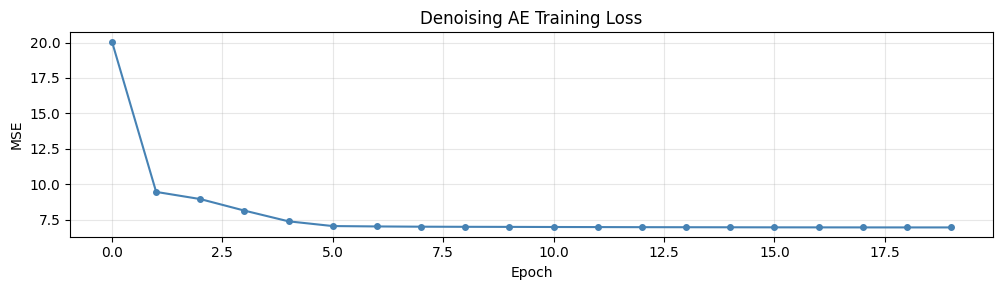

In [65]:
if ae_history:
    plt.figure(figsize=(10, 3))
    plt.plot(ae_history, marker="o", ms=4, color="steelblue")
    plt.title("Denoising AE Training Loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 8. Fine-tune: Severity Classification (5-fold Cross Validation)

In [66]:
def train_fold(X_tr, y_tr, X_va, y_va, pretrained_base, fold_idx,
               ft_epochs=FT_EPOCHS, batch_size=FT_BATCH):
    """Fine-tune a severity classifier on one fold."""
    model = TelemetryClassifier(copy.deepcopy(pretrained_base),
                                N_CLASSES, EMBED_DIM).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.long)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t),
                        batch_size=batch_size, shuffle=True)

    # Correct calculation of steps_per_epoch
    sched   = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=5e-4, steps_per_epoch=len(loader),
        epochs=ft_epochs)
    loss_fn = nn.CrossEntropyLoss()

    best_f1, best_state = 0.0, None
    for epoch in range(1, ft_epochs + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        # Validation
        model.eval()
        with torch.no_grad():
            Xva_t  = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
            logits = model(Xva_t)
            preds  = logits.argmax(dim=1).cpu().numpy()
        val_f1 = f1_score(y_va, preds, average="macro")
        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    torch.save(best_state,
               os.path.join(MODEL_DIR, f"classifier_fold{fold_idx}.pt"))
    # Final OOF predictions
    model.eval()
    with torch.no_grad():
        Xva_t  = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
        preds  = model(Xva_t).argmax(dim=1).cpu().numpy()
    print(f"  Fold {fold_idx}  val macro-F1: {best_f1:.4f}")
    return preds, best_f1


import copy

skf      = StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_preds = np.zeros(len(y_all), dtype=np.float32)
scores    = []

folds = list(skf.split(X_all, y_all))
if ONE_FOLD:
    folds = folds[:1]

for fold_idx, (tr_idx, va_idx) in enumerate(folds):
    print(f"\n─── Fold {fold_idx} ───")
    preds, f1 = train_fold(
        X_all[tr_idx], y_all[tr_idx],
        X_all[va_idx], y_all[va_idx],
        ae_model, fold_idx)
    oof_preds[va_idx] = preds
    scores.append(f1)

print(f"\nMean macro-F1: {np.mean(scores):.4f} \u00b1 {np.std(scores):.4f}")


─── Fold 0 ───
  Fold 0  val macro-F1: 0.9242

─── Fold 1 ───
  Fold 1  val macro-F1: 0.9310

─── Fold 2 ───
  Fold 2  val macro-F1: 0.9335

─── Fold 3 ───
  Fold 3  val macro-F1: 0.9227

─── Fold 4 ───
  Fold 4  val macro-F1: 0.9344

Mean macro-F1: 0.9292 ± 0.0048


## 9. Evaluation

In [67]:
# ── OOF Classification Report ──────────────────────────────────────────────
print("=== Out-of-Fold Classification Report ===")
print(classification_report(
    y_all, oof_preds.astype(int),
    target_names=le_severity.classes_
))

=== Out-of-Fold Classification Report ===
              precision    recall  f1-score   support

       error       0.89      0.92      0.91      3786
        info       0.96      0.92      0.94      8964
     warning       0.92      0.96      0.94      6877

    accuracy                           0.93     19627
   macro avg       0.93      0.93      0.93     19627
weighted avg       0.94      0.93      0.93     19627



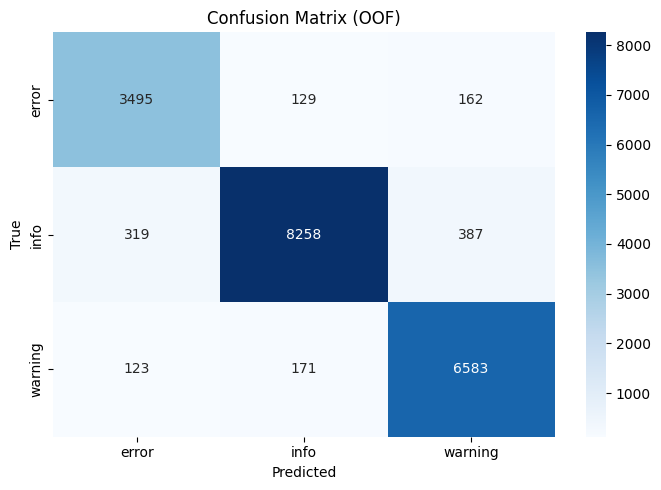

In [68]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_all, oof_preds.astype(int))
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_severity.classes_,
            yticklabels=le_severity.classes_)
plt.title("Confusion Matrix (OOF)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

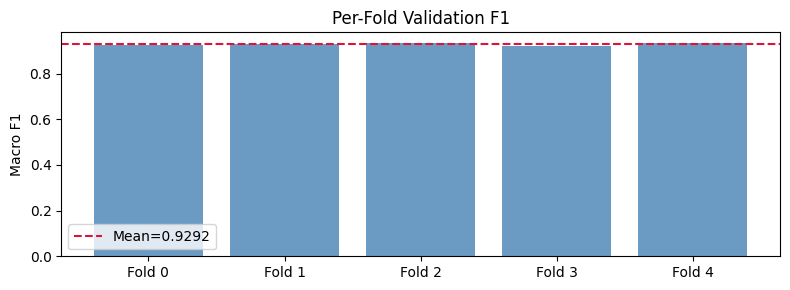

In [69]:
# ── Fold F1 bar chart ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.bar(range(len(scores)), scores, color="steelblue", alpha=0.8)
plt.axhline(np.mean(scores), color="crimson", linestyle="--",
            label=f"Mean={np.mean(scores):.4f}")
plt.xticks(range(len(scores)), [f"Fold {i}" for i in range(len(scores))])
plt.ylabel("Macro F1"); plt.title("Per-Fold Validation F1")
plt.legend(); plt.tight_layout(); plt.show()

## 10. Anomaly Detection via AE Reconstruction Error

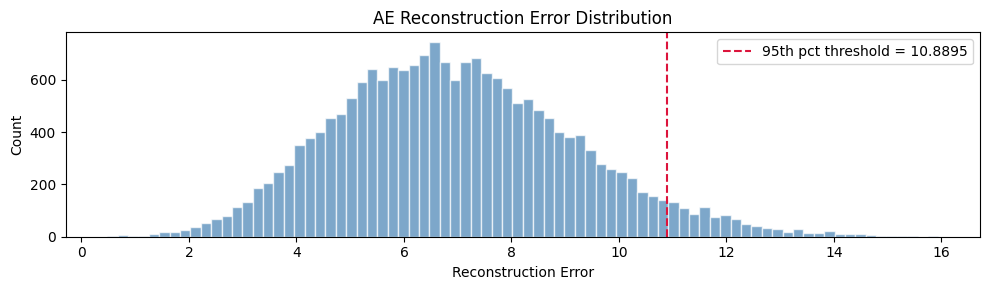

Threshold (95th pct): 10.88947
Anomalies flagged:    982 / 19,627 (5.0%)


In [70]:
# Use AE reconstruction error as an unsupervised anomaly score
ae_model.eval()
X_t          = torch.tensor(X_all, dtype=torch.float32)
CHUNK        = 256
recon_errors = []

with torch.no_grad():
    for start in range(0, len(X_t), CHUNK):
        xb    = X_t[start:start + CHUNK].to(DEVICE)
        x_hat = ae_model(xb)
        err   = (x_hat - xb).pow(2).mean(dim=(1, 2)).cpu().numpy()
        recon_errors.extend(err.tolist())

recon_errors  = np.array(recon_errors)
threshold     = np.percentile(recon_errors, 95)
anomaly_mask  = recon_errors > threshold

# Distribution plot
plt.figure(figsize=(10, 3))
plt.hist(recon_errors, bins=80, color="steelblue", alpha=0.7, edgecolor="white")
plt.axvline(threshold, color="crimson", linestyle="--",
            label=f"95th pct threshold = {threshold:.4f}")
plt.xlabel("Reconstruction Error"); plt.ylabel("Count")
plt.title("AE Reconstruction Error Distribution")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Threshold (95th pct): {threshold:.5f}")
print(f"Anomalies flagged:    {anomaly_mask.sum():,} / {len(anomaly_mask):,} "
      f"({100 * anomaly_mask.mean():.1f}%)")

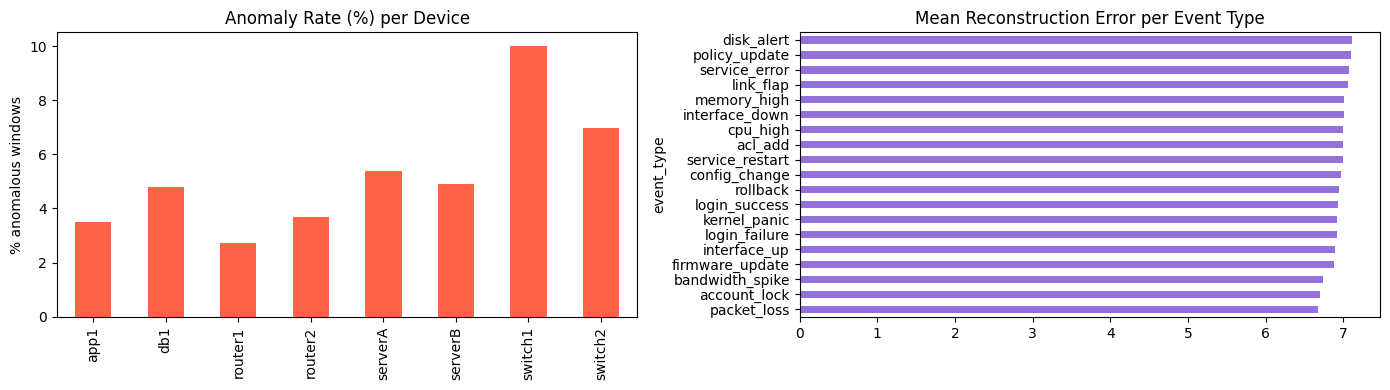


Top 10 anomalous windows:


,device,event_type,severity,recon_error
16445,switch1,disk_alert,warning,15.944109
5780,db1,cpu_high,warning,15.496834
11168,serverA,policy_update,info,15.470762
9007,router2,login_success,info,15.418697
16271,switch1,cpu_high,warning,15.328969
13579,serverB,memory_high,warning,15.185847
16272,switch1,cpu_high,warning,15.164681
13580,serverB,service_error,info,15.104038
13575,serverB,config_change,info,15.021646
16444,switch1,config_change,info,14.998423


In [71]:
# Anomaly distribution across devices & event types
window_devices = []
window_events  = []
window_sev     = []
for dev_id, grp in df.sort_values("timestamp").groupby("device_id"):
    evts = grp["event_type"].values
    sevs = grp["severity"].values
    for start in range(len(grp) - WINDOW + 1):
        window_devices.append(le_device.classes_[dev_id])
        window_events.append(evts[start + WINDOW - 1])
        window_sev.append(sevs[start + WINDOW - 1])

anom_df = pd.DataFrame({
    "device"      : window_devices,
    "event_type"  : window_events,
    "severity"    : window_sev,
    "recon_error" : recon_errors,
    "is_anomaly"  : anomaly_mask,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anom_df.groupby("device")["is_anomaly"].mean().mul(100).plot(
    kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Anomaly Rate (%) per Device")
axes[0].set_ylabel("% anomalous windows"); axes[0].set_xlabel("")

anom_df.groupby("event_type")["recon_error"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Mean Reconstruction Error per Event Type")

plt.tight_layout(); plt.show()

print("\nTop 10 anomalous windows:")
anom_df.nlargest(10, "recon_error")[["device", "event_type", "severity", "recon_error"]]

### Anomaly Prediction Confusion Matrix

To evaluate the anomaly detection performance with a confusion matrix, we first need to define a 'true' anomaly label. For this example, we'll consider events with severity 'error' or 'warning' as true anomalies, and 'info' events as normal. Then, we'll compare these true labels with the `is_anomaly` predictions from the Denoising Autoencoder.

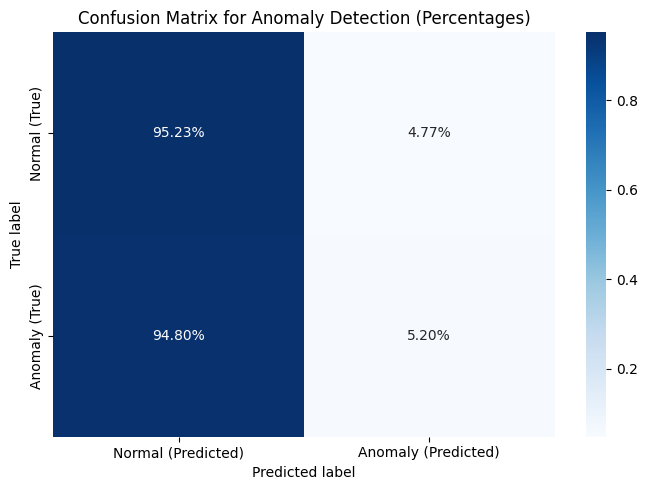

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define 'true' anomaly based on severity
anom_df['true_anomaly'] = anom_df['severity'].isin(['error', 'warning'])

# Calculate confusion matrix
cm_anomaly = confusion_matrix(anom_df['true_anomaly'], anom_df['is_anomaly'])

# Calculate percentages
cm_percentage = cm_anomaly.astype('float') / cm_anomaly.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 5))
sns.heatmap(cm_percentage, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Normal (Predicted)", "Anomaly (Predicted)"],
            yticklabels=["Normal (True)", "Anomaly (True)"])
plt.title("Confusion Matrix for Anomaly Detection (Percentages)")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

## 11. Summary

In [73]:
print("=" * 60)
print("  ARISTA TELEMETRY ANOMALY DETECTION — RESULTS SUMMARY")
print("=" * 60)
print(f"\n  Dataset:        {len(df):,} events  |  {N_DEVICES} devices  |  {N_EVENTS} event types")
print(f"  Feature cols:   {N_FEATURES} (event_id + source_id + {len(NUM_COLS)} numeric)")
print(f"  Windows:        {len(X_all):,} sequences of length {WINDOW}")
print(f"  AE Pretraining: {AE_EPOCHS} epochs  |  noise α={DENOISE_ALPHA}")
print(f"  Fine-tune:      {FT_EPOCHS} epochs  |  {N_FOLDS}-fold CV")
print(f"\n  Severity Classification (OOF):")
print(f"    Mean Macro F1 : {np.mean(scores):.4f} ± {np.std(scores):.4f}")
print(f"    Fold scores   : {[round(s, 4) for s in scores]}")
print(f"\n  Anomaly Detection (AE reconstruction error):")
print(f"    Threshold (95th pct) : {threshold:.5f}")
print(f"    Anomalies flagged    : {anomaly_mask.sum():,} windows "
      f"({100 * anomaly_mask.mean():.1f}%)")
print(f"\n  Models saved in: {MODEL_DIR}/")
print("=" * 60)

  ARISTA TELEMETRY ANOMALY DETECTION — RESULTS SUMMARY

  Dataset:        19,747 events  |  8 devices  |  19 event types
  Feature cols:   2 (event_id + source_id + 0 numeric)
  Windows:        19,627 sequences of length 16
  AE Pretraining: 20 epochs  |  noise α=0.15
  Fine-tune:      30 epochs  |  5-fold CV

  Severity Classification (OOF):
    Mean Macro F1 : 0.9292 ± 0.0048
    Fold scores   : [0.9242, 0.931, 0.9335, 0.9227, 0.9344]

  Anomaly Detection (AE reconstruction error):
    Threshold (95th pct) : 10.88947
    Anomalies flagged    : 982 windows (5.0%)

  Models saved in: ./models/
